## Imports

Loads all required libraries for modeling, preprocessing and evaluation.
Warnings are suppressed to keep output clean.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from scipy.signal import savgol_filter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA RTX A6000


## Location Specific Cysteine Labels

Defines 60 HPLC cysteine labels, one per cultivar per growing location.
This is richer than the previous 20 mean labels because it captures
how growing environment affects cysteine concentration.
The label for each spectrum is determined by both cultivar name and location.

In [2]:
CYSTEINE_LABELS_LOCATION = {
    ("AAC Chrome",     "Limerick"):   0.3105,
    ("AAC Chrome",     "Rosthern"):   0.3312,
    ("AAC Chrome",     "Sutherland"): 0.3100,
    ("AAC Lacombe",    "Limerick"):   0.3712,
    ("AAC Lacombe",    "Rosthern"):   0.3145,
    ("AAC Lacombe",    "Sutherland"): 0.3300,
    ("AAC Liscard",    "Limerick"):   0.3606,
    ("AAC Liscard",    "Rosthern"):   0.2756,
    ("AAC Liscard",    "Sutherland"): 0.3400,
    ("CDC Amarillo",   "Limerick"):   0.4158,
    ("CDC Amarillo",   "Rosthern"):   0.3510,
    ("CDC Amarillo",   "Sutherland"): 0.3100,
    ("CDC Athabasca",  "Limerick"):   0.3570,
    ("CDC Athabasca",  "Rosthern"):   0.3266,
    ("CDC Athabasca",  "Sutherland"): 0.3400,
    ("CDC Canary",     "Limerick"):   0.3181,
    ("CDC Canary",     "Rosthern"):   0.3053,
    ("CDC Canary",     "Sutherland"): 0.3200,
    ("CDC Dakota",     "Limerick"):   0.3599,
    ("CDC Dakota",     "Rosthern"):   0.2986,
    ("CDC Dakota",     "Sutherland"): 0.3400,
    ("CDC Golden",     "Limerick"):   0.3236,
    ("CDC Golden",     "Rosthern"):   0.3836,
    ("CDC Golden",     "Sutherland"): 0.3700,
    ("CDC Greenwater", "Limerick"):   0.3506,
    ("CDC Greenwater", "Rosthern"):   0.3385,
    ("CDC Greenwater", "Sutherland"): 0.3500,
    ("CDC Inca",       "Limerick"):   0.3918,
    ("CDC Inca",       "Rosthern"):   0.3542,
    ("CDC Inca",       "Sutherland"): 0.3500,
    ("CDC Jasper",     "Limerick"):   0.3290,
    ("CDC Jasper",     "Rosthern"):   0.3430,
    ("CDC Jasper",     "Sutherland"): 0.3400,
    ("CDC Striker",    "Limerick"):   0.3446,
    ("CDC Striker",    "Rosthern"):   0.3703,
    ("CDC Striker",    "Sutherland"): 0.3200,
    ("CDC Lewochko",   "Limerick"):   0.3850,
    ("CDC Lewochko",   "Rosthern"):   0.3088,
    ("CDC Lewochko",   "Sutherland"): 0.3300,
    ("CDC Meadow",     "Limerick"):   0.3250,
    ("CDC Meadow",     "Rosthern"):   0.3110,
    ("CDC Meadow",     "Sutherland"): 0.3000,
    ("CDC Patrick",    "Limerick"):   0.3302,
    ("CDC Patrick",    "Rosthern"):   0.3950,
    ("CDC Patrick",    "Sutherland"): 0.2900,
    ("CDC Saffron",    "Limerick"):   0.3326,
    ("CDC Saffron",    "Rosthern"):   0.3778,
    ("CDC Saffron",    "Sutherland"): 0.3300,
    ("CDC Spectrum",   "Limerick"):   0.4142,
    ("CDC Spectrum",   "Rosthern"):   0.3753,
    ("CDC Spectrum",   "Sutherland"): 0.3300,
    ("CDC Spruce",     "Limerick"):   0.3516,
    ("CDC Spruce",     "Rosthern"):   0.3555,
    ("CDC Spruce",     "Sutherland"): 0.3300,
    ("CDC Tetris",     "Limerick"):   0.3507,
    ("CDC Tetris",     "Rosthern"):   0.3554,
    ("CDC Tetris",     "Sutherland"): 0.3200,
    ("Redbat 88",      "Limerick"):   0.2965,
    ("Redbat 88",      "Rosthern"):   0.3423,
    ("Redbat 88",      "Sutherland"): 0.3100,
}

print(f"Total unique labels: {len(CYSTEINE_LABELS_LOCATION)}")
print(f"20 cultivars x 3 locations = 60 labels")

Total unique labels: 60
20 cultivars x 3 locations = 60 labels


## Load FTIR Dataset and Assign Location Specific Labels

Loads the FTIR spectra from the Excel file.
Each spectrum is assigned a cysteine label based on both its cultivar name
and growing location, giving 60 unique labels instead of the previous 20.
This captures the effect of growing environment on cysteine concentration.

In [3]:
FTIR_PATH = Path("/home/priyanshu/Research/Dataset/FTIR_raw_spectra_working.xlsx")

df = pd.read_excel(FTIR_PATH, sheet_name='Sheet2', header=0)

sample_names = df.iloc[:, 0].values
locations    = df.iloc[:, 1].values
wavenumbers  = df.columns[2:].astype(float).values
X_ftir       = df.iloc[:, 2:].values.astype(float)

# Assign location specific labels
y_ftir = np.array([
    CYSTEINE_LABELS_LOCATION[(name, loc)]
    for name, loc in zip(sample_names, locations)
])

cultivar_names  = list(np.unique(sample_names))
location_names  = list(np.unique(locations))

print(f"X shape:          {X_ftir.shape}")
print(f"y shape:          {y_ftir.shape}")
print(f"Cultivars:        {len(cultivar_names)}")
print(f"Locations:        {location_names}")
print(f"\nOld cysteine range (mean labels): 0.3120 to 0.3732")
print(f"New cysteine range (location labels): {y_ftir.min():.4f} to {y_ftir.max():.4f}")
print(f"New spread: {y_ftir.max() - y_ftir.min():.4f} vs old spread 0.0612")
print(f"\nSamples per location:")
for loc in location_names:
    print(f"  {loc}: {np.sum(locations == loc)} spectra")

X shape:          (180, 2527)
y shape:          (180,)
Cultivars:        20
Locations:        ['Limerick', 'Rosthern', 'Sutherland']

Old cysteine range (mean labels): 0.3120 to 0.3732
New cysteine range (location labels): 0.2756 to 0.4158
New spread: 0.1402 vs old spread 0.0612

Samples per location:
  Limerick: 60 spectra
  Rosthern: 61 spectra
  Sutherland: 59 spectra


## Preprocessing Functions

Defines all preprocessing functions. Based on previous FTIR experiments,
SG plus MSC plus 1st derivative was the best combination for SVR and
SG plus SNV plus 1st derivative was best for RF under LOCO.
The MSC fix ensures the reference mean is computed on the training fold only.

In [4]:
def savitzky_golay_smooth(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, axis=1)

def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / std

def msc_fit_transform(X_train, X_test):
    mean_spectrum = X_train.mean(axis=0)
    def correct_one(spectrum):
        coef = np.polyfit(mean_spectrum, spectrum, 1)
        return (spectrum - coef[1]) / coef[0]
    X_train_msc = np.array([correct_one(s) for s in X_train])
    X_test_msc  = np.array([correct_one(s) for s in X_test])
    return X_train_msc, X_test_msc

def first_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=1, axis=1)

def second_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=2, axis=1)

def preprocess_best_svr(X_train, X_test):
    """SG plus MSC plus 1st derivative — best for SVR on FTIR"""
    X_tr_sg = savitzky_golay_smooth(X_train)
    X_te_sg = savitzky_golay_smooth(X_test)
    X_tr_msc, X_te_msc = msc_fit_transform(X_tr_sg, X_te_sg)
    return first_derivative(X_tr_msc), first_derivative(X_te_msc)

def preprocess_best_rf(X_train, X_test):
    """SG plus SNV plus 1st derivative — best for RF on FTIR"""
    X_tr = first_derivative(snv(savitzky_golay_smooth(X_train)))
    X_te = first_derivative(snv(savitzky_golay_smooth(X_test)))
    return X_tr, X_te

def preprocess_best_plsr(X_train, X_test):
    """SG plus SNV plus 2nd derivative — best for PLSR on FTIR"""
    X_tr = second_derivative(snv(savitzky_golay_smooth(X_train)))
    X_te = second_derivative(snv(savitzky_golay_smooth(X_test)))
    return X_tr, X_te

print("Preprocessing functions defined!")

Preprocessing functions defined!


## CNN Architecture and Training Function

Same 1D CNN architecture used in previous experiments.
Input size updated to 2527 to match FTIR spectral length.
Fixed training function with no validation set prevents data leakage.
Small batch size of 8 used because FTIR has very few samples per fold.

In [5]:
class CNN1D(nn.Module):
    def __init__(self, input_size=2527):
        super(CNN1D, self).__init__()
        self.conv_blocks = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
        )
        self.flat_size = 128 * (input_size // 16)
        self.fc_layers = nn.Sequential(
            nn.Linear(self.flat_size, 128),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv_blocks(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x.squeeze(1)

def train_cnn_fixed(model, X_train, y_train,
                    epochs=100, batch_size=8, lr=1e-4):
    X_tr = torch.FloatTensor(X_train).to(device)
    y_tr = torch.FloatTensor(y_train).to(device)
    dataset  = TensorDataset(X_tr, y_tr)
    loader   = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    criterion = nn.SmoothL1Loss(beta=0.02)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
                    optimizer, max_lr=lr,
                    steps_per_epoch=len(loader), epochs=epochs)
    model.to(device)
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
    return model

model_test = CNN1D(input_size=2527)
dummy = torch.randn(4, 2527)
out   = model_test(dummy)
print(f"Total parameters: {sum(p.numel() for p in model_test.parameters()):,}")
print(f"Output shape: {out.shape}")

Total parameters: 2,627,105
Output shape: torch.Size([4])


## Splitting Strategy 1: Leave One Location Out (LOLO)

Train on spectra from 2 locations, test on the 3rd location.
Repeat 3 times, once for each location as the test set.
This tests whether the model generalises across

In [6]:
def run_lolo(model_type='svr', preprocess_fn=None):
    """
    Leave One Location Out cross validation.
    Train on 2 locations, test on the held out location.
    Repeat for all 3 locations.
    """
    print(f"\nRunning LOLO for: {model_type.upper()}")
    all_true, all_pred = [], []
    fold_results = []

    for held_out_loc in location_names:
        train_mask = locations != held_out_loc
        test_mask  = locations == held_out_loc

        X_tr_raw = X_ftir[train_mask]
        y_tr     = y_ftir[train_mask]
        X_te_raw = X_ftir[test_mask]
        y_te     = y_ftir[test_mask]

        # Apply preprocessing
        if preprocess_fn is not None:
            X_tr_l, X_te_l = preprocess_fn(X_tr_raw, X_te_raw)
        else:
            X_tr_l, X_te_l = X_tr_raw.copy(), X_te_raw.copy()

        if model_type == 'plsr':
            n_comp = min(10, X_tr_l.shape[0] - 1)
            model  = PLSRegression(n_components=n_comp)
            model.fit(X_tr_l, y_tr)
            pred = model.predict(X_te_l).flatten()

        elif model_type == 'svr':
            scaler  = StandardScaler()
            X_tr_s  = scaler.fit_transform(X_tr_l)
            X_te_s  = scaler.transform(X_te_l)
            model   = SVR(kernel='rbf', C=10, epsilon=0.001, gamma='auto')
            model.fit(X_tr_s, y_tr)
            pred = model.predict(X_te_s)

        elif model_type == 'rf':
            model = RandomForestRegressor(
                n_estimators=200, random_state=42, n_jobs=-1
            )
            model.fit(X_tr_l, y_tr)
            pred = model.predict(X_te_l)

        elif model_type == 'cnn':
            input_size = X_tr_l.shape[1]
            torch.manual_seed(42)
            cnn = CNN1D(input_size=input_size).to(device)
            cnn = train_cnn_fixed(cnn, X_tr_l, y_tr, epochs=100)
            cnn.eval()
            with torch.no_grad():
                pred = cnn(
                    torch.FloatTensor(X_te_l).to(device)
                ).cpu().numpy()

        rmse = np.sqrt(mean_squared_error(y_te, pred))
        r2   = r2_score(y_te, pred)
        rpd  = y_te.std() / rmse

        print(f"  Held out {held_out_loc:12s} "
              f"RMSE={rmse:.4f}  R²={r2:.4f}  RPD={rpd:.4f}  "
              f"n_train={len(y_tr)}  n_test={len(y_te)}")

        fold_results.append({
            "location": held_out_loc,
            "rmse": rmse, "r2": r2, "rpd": rpd
        })
        all_true.extend(y_te)
        all_pred.extend(pred)

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    rmse_global = np.sqrt(mean_squared_error(all_true, all_pred))
    r2_global   = r2_score(all_true, all_pred)
    rpd_global  = all_true.std() / rmse_global

    print(f"\n  Global LOLO RMSE={rmse_global:.4f}  "
          f"R²={r2_global:.4f}  RPD={rpd_global:.4f}")

    return rmse_global, r2_global, rpd_global, all_true, all_pred, fold_results

print("LOLO function defined!")

LOLO function defined!


## Splitting Strategy 2: Leave One Cultivar Out (LOCO)

Hold out all spectra from one cultivar, train on remaining 19 cultivars.
Each spectrum gets its location specific cysteine label.
Repeat 20 times, once for each cultivar as the test set.
This tests whether the model generalises to completely unseen cultivars.

In [7]:
def run_loco(model_type='svr', preprocess_fn=None):
    """
    Leave One Cultivar Out cross validation.
    Train on 19 cultivars, test on the held out cultivar.
    Each spectrum uses its location specific cysteine label.
    """
    print(f"\nRunning LOCO for: {model_type.upper()}")
    all_true, all_pred = [], []
    fold_results = []

    for held_out_cult in cultivar_names:
        train_mask = sample_names != held_out_cult
        test_mask  = sample_names == held_out_cult

        X_tr_raw = X_ftir[train_mask]
        y_tr     = y_ftir[train_mask]
        X_te_raw = X_ftir[test_mask]
        y_te     = y_ftir[test_mask]

        # Apply preprocessing
        if preprocess_fn is not None:
            X_tr_l, X_te_l = preprocess_fn(X_tr_raw, X_te_raw)
        else:
            X_tr_l, X_te_l = X_tr_raw.copy(), X_te_raw.copy()

        if model_type == 'plsr':
            n_comp = min(10, X_tr_l.shape[0] - 1)
            model  = PLSRegression(n_components=n_comp)
            model.fit(X_tr_l, y_tr)
            pred = model.predict(X_te_l).flatten()

        elif model_type == 'svr':
            scaler  = StandardScaler()
            X_tr_s  = scaler.fit_transform(X_tr_l)
            X_te_s  = scaler.transform(X_te_l)
            model   = SVR(kernel='rbf', C=10, epsilon=0.001, gamma='auto')
            model.fit(X_tr_s, y_tr)
            pred = model.predict(X_te_s)

        elif model_type == 'rf':
            model = RandomForestRegressor(
                n_estimators=200, random_state=42, n_jobs=-1
            )
            model.fit(X_tr_l, y_tr)
            pred = model.predict(X_te_l)

        elif model_type == 'cnn':
            input_size = X_tr_l.shape[1]
            torch.manual_seed(42)
            cnn = CNN1D(input_size=input_size).to(device)
            cnn = train_cnn_fixed(cnn, X_tr_l, y_tr, epochs=100)
            cnn.eval()
            with torch.no_grad():
                pred = cnn(
                    torch.FloatTensor(X_te_l).to(device)
                ).cpu().numpy()

        rmse = np.sqrt(mean_squared_error(y_te, pred))
        r2   = r2_score(y_te, pred)
        rpd  = y_te.std() / rmse

        print(f"  Held out {held_out_cult:20s} "
              f"RMSE={rmse:.4f}  R²={r2:.4f}  RPD={rpd:.4f}")

        fold_results.append({
            "cultivar": held_out_cult,
            "rmse": rmse, "r2": r2, "rpd": rpd
        })
        all_true.extend(y_te)
        all_pred.extend(pred)

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    rmse_global = np.sqrt(mean_squared_error(all_true, all_pred))
    r2_global   = r2_score(all_true, all_pred)
    rpd_global  = all_true.std() / rmse_global

    print(f"\n  Global LOCO RMSE={rmse_global:.4f}  "
          f"R²={r2_global:.4f}  RPD={rpd_global:.4f}")

    return rmse_global, r2_global, rpd_global, all_true, all_pred, fold_results

print("LOCO function defined!")

LOCO function defined!


## Splitting Strategy 3: 80/20 Random Split by Cultivar

Randomly assigns 16 cultivars to training and 4 cultivars to test.
Splitting by cultivar ensures no data leakage between train and test sets.
If splitting by individual spectra, the same cultivar could appear in both
train and test which would cause leakage since labels are cultivar specific.
Repeated 10 times with different random seeds for reliable estimates.

In [8]:
def run_8020(model_type='svr', preprocess_fn=None, n_repeats=10):
    """
    80/20 split by cultivar to prevent data leakage.
    16 cultivars for training, 4 for testing.
    Repeated n_repeats times with different seeds.
    """
    print(f"\nRunning 80/20 for: {model_type.upper()}")
    all_r2, all_rmse, all_rpd = [], [], []

    for seed in range(n_repeats):
        np.random.seed(seed)
        shuffled = np.random.permutation(cultivar_names)
        n_test   = max(1, int(len(cultivar_names) * 0.2))
        test_cultivars  = shuffled[:n_test]
        train_cultivars = shuffled[n_test:]

        train_mask = np.isin(sample_names, train_cultivars)
        test_mask  = np.isin(sample_names, test_cultivars)

        X_tr_raw = X_ftir[train_mask]
        y_tr     = y_ftir[train_mask]
        X_te_raw = X_ftir[test_mask]
        y_te     = y_ftir[test_mask]

        # Apply preprocessing
        if preprocess_fn is not None:
            X_tr_l, X_te_l = preprocess_fn(X_tr_raw, X_te_raw)
        else:
            X_tr_l, X_te_l = X_tr_raw.copy(), X_te_raw.copy()

        if model_type == 'plsr':
            n_comp = min(10, X_tr_l.shape[0] - 1)
            model  = PLSRegression(n_components=n_comp)
            model.fit(X_tr_l, y_tr)
            pred = model.predict(X_te_l).flatten()

        elif model_type == 'svr':
            scaler  = StandardScaler()
            X_tr_s  = scaler.fit_transform(X_tr_l)
            X_te_s  = scaler.transform(X_te_l)
            model   = SVR(kernel='rbf', C=10, epsilon=0.001, gamma='auto')
            model.fit(X_tr_s, y_tr)
            pred = model.predict(X_te_s)

        elif model_type == 'rf':
            model = RandomForestRegressor(
                n_estimators=200, random_state=42, n_jobs=-1
            )
            model.fit(X_tr_l, y_tr)
            pred = model.predict(X_te_l)

        elif model_type == 'cnn':
            input_size = X_tr_l.shape[1]
            torch.manual_seed(seed)
            cnn = CNN1D(input_size=input_size).to(device)
            cnn = train_cnn_fixed(cnn, X_tr_l, y_tr, epochs=100)
            cnn.eval()
            with torch.no_grad():
                pred = cnn(
                    torch.FloatTensor(X_te_l).to(device)
                ).cpu().numpy()

        rmse = np.sqrt(mean_squared_error(y_te, pred))
        r2   = r2_score(y_te, pred)
        rpd  = y_te.std() / rmse

        all_r2.append(r2)
        all_rmse.append(rmse)
        all_rpd.append(rpd)
        print(f"  Seed {seed:2d}: RMSE={rmse:.4f}  R²={r2:.4f}  RPD={rpd:.4f}  "
              f"test cultivars={list(test_cultivars)}")

    print(f"\n  Mean RMSE={np.mean(all_rmse):.4f} +/- {np.std(all_rmse):.4f}")
    print(f"  Mean R²  ={np.mean(all_r2):.4f} +/- {np.std(all_r2):.4f}")
    print(f"  Mean RPD ={np.mean(all_rpd):.4f} +/- {np.std(all_rpd):.4f}")

    return np.mean(all_rmse), np.mean(all_r2), np.mean(all_rpd), \
           np.std(all_rmse), np.std(all_r2), np.std(all_rpd)

print("80/20 function defined!")

80/20 function defined!


## Run All Models Under All Splitting Strategies

Runs PLSR, SVR, RF and CNN under all three splitting strategies.
Uses the best preprocessing found in previous FTIR experiments for each model.
Results are stored for comparison and plotting.

In [9]:
results_all = {}

strategies = {
    "LOLO": run_lolo,
    "LOCO": run_loco,
    "80/20": run_8020,
}

preprocess_fns = {
    "PLSR": preprocess_best_plsr,
    "SVR":  preprocess_best_svr,
    "RF":   preprocess_best_rf,
    "CNN":  preprocess_best_svr,  # use same as SVR for CNN
}

model_types = {
    "PLSR": "plsr",
    "SVR":  "svr",
    "RF":   "rf",
    "CNN":  "cnn",
}

for strategy_name, strategy_fn in strategies.items():
    print(f"\n{'='*60}")
    print(f"STRATEGY: {strategy_name}")
    print(f"{'='*60}")
    results_all[strategy_name] = {}

    for model_name, model_type in model_types.items():
        print(f"\n--- {model_name} ---")
        preprocess_fn = preprocess_fns[model_name]

        if strategy_name == "80/20":
            rmse, r2, rpd, rmse_std, r2_std, rpd_std = strategy_fn(
                model_type=model_type,
                preprocess_fn=preprocess_fn,
                n_repeats=10
            )
            results_all[strategy_name][model_name] = {
                "rmse": rmse, "r2": r2, "rpd": rpd,
                "rmse_std": rmse_std, "r2_std": r2_std, "rpd_std": rpd_std
            }
        else:
            rmse, r2, rpd, yt, yp, folds = strategy_fn(
                model_type=model_type,
                preprocess_fn=preprocess_fn
            )
            results_all[strategy_name][model_name] = {
                "rmse": rmse, "r2": r2, "rpd": rpd,
                "true": yt, "pred": yp, "folds": folds
            }

print("\n\nALL DONE!")


STRATEGY: LOLO

--- PLSR ---

Running LOLO for: PLSR
  Held out Limerick     RMSE=0.0360  R²=-0.2895  RPD=0.8806  n_train=120  n_test=60
  Held out Rosthern     RMSE=0.0447  R²=-1.1261  RPD=0.6858  n_train=119  n_test=61
  Held out Sutherland   RMSE=0.0338  R²=-2.3922  RPD=0.5430  n_train=121  n_test=59

  Global LOLO RMSE=0.0385  R²=-0.7483  RPD=0.7563

--- SVR ---

Running LOLO for: SVR
  Held out Limerick     RMSE=0.0351  R²=-0.2297  RPD=0.9018  n_train=120  n_test=60
  Held out Rosthern     RMSE=0.0339  R²=-0.2239  RPD=0.9039  n_train=119  n_test=61
  Held out Sutherland   RMSE=0.0298  R²=-1.6429  RPD=0.6151  n_train=121  n_test=59

  Global LOLO RMSE=0.0330  R²=-0.2882  RPD=0.8811

--- RF ---

Running LOLO for: RF
  Held out Limerick     RMSE=0.0392  R²=-0.5360  RPD=0.8069  n_train=120  n_test=60
  Held out Rosthern     RMSE=0.0360  R²=-0.3819  RPD=0.8507  n_train=119  n_test=61
  Held out Sutherland   RMSE=0.0273  R²=-1.2129  RPD=0.6722  n_train=121  n_test=59

  Global LOLO RMS

In [10]:
print("\n" + "="*75)
print("   COMPLETE RESULTS: ALL MODELS x ALL STRATEGIES")
print("="*75)
print(f"{'Model':<8} {'Strategy':<10} {'RMSE':>8} {'R²':>8} {'RPD':>8}")
print("-"*75)

for strategy_name in ["LOLO", "LOCO", "80/20"]:
    for model_name in ["PLSR", "SVR", "RF", "CNN"]:
        res = results_all[strategy_name][model_name]
        if strategy_name == "80/20":
            print(f"{model_name:<8} {strategy_name:<10} "
                  f"{res['rmse']:>8.4f} {res['r2']:>8.4f} {res['rpd']:>8.4f} "
                  f"(+/- {res['r2_std']:.4f})")
        else:
            print(f"{model_name:<8} {strategy_name:<10} "
                  f"{res['rmse']:>8.4f} {res['r2']:>8.4f} {res['rpd']:>8.4f}")
    print()

print("="*75)

# Previous results for comparison
print("\nComparison with previous FTIR results (mean labels):")
print(f"  SVR LOCO (mean labels):  R²= 0.0938")
print(f"  RF  LOCO (mean labels):  R²= 0.0733")
print(f"  PLSR LOCO (mean labels): R²=-0.0624")


   COMPLETE RESULTS: ALL MODELS x ALL STRATEGIES
Model    Strategy       RMSE       R²      RPD
---------------------------------------------------------------------------
PLSR     LOLO         0.0385  -0.7483   0.7563
SVR      LOLO         0.0330  -0.2882   0.8811
RF       LOLO         0.0346  -0.4124   0.8414
CNN      LOLO         0.0416  -1.0377   0.7005

PLSR     LOCO         0.0357  -0.5059   0.8149
SVR      LOCO         0.0291  -0.0021   0.9990
RF       LOCO         0.0286   0.0370   1.0190
CNN      LOCO         0.0328  -0.2666   0.8886

PLSR     80/20        0.0359  -0.8288   0.7873 (+/- 0.7039)
SVR      80/20        0.0285  -0.1144   0.9611 (+/- 0.2091)
RF       80/20        0.0281  -0.0847   0.9818 (+/- 0.2561)
CNN      80/20        0.0328  -0.4715   0.8773 (+/- 0.5431)


Comparison with previous FTIR results (mean labels):
  SVR LOCO (mean labels):  R²= 0.0938
  RF  LOCO (mean labels):  R²= 0.0733
  PLSR LOCO (mean labels): R²=-0.0624


## Results Visualisation

Scatter plots and bar charts comparing all models under all three strategies.
Each cultivar or location is shown in a different colour in the scatter plots.

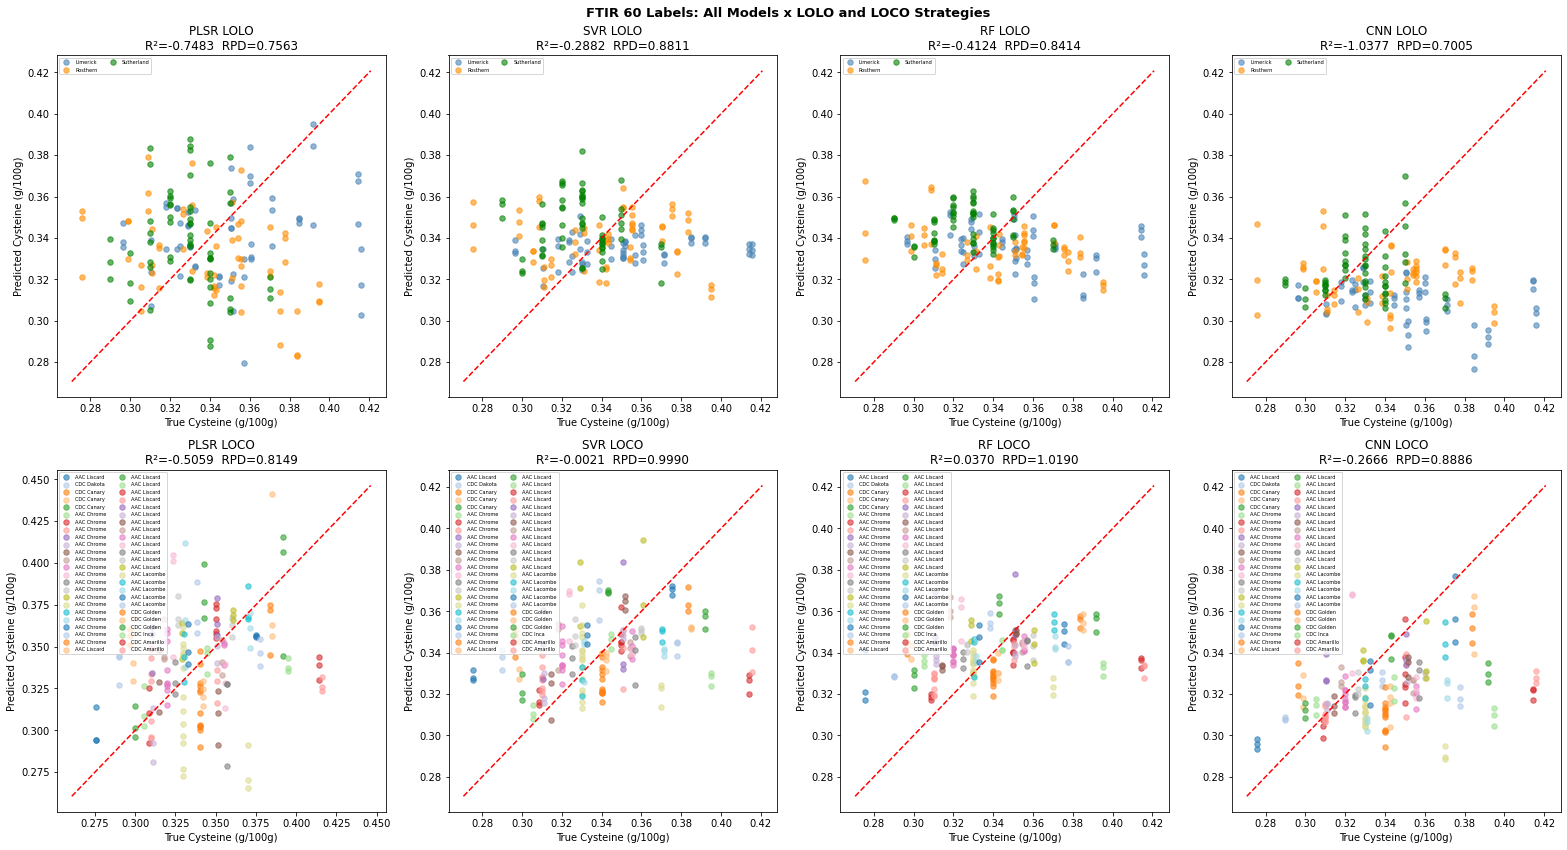

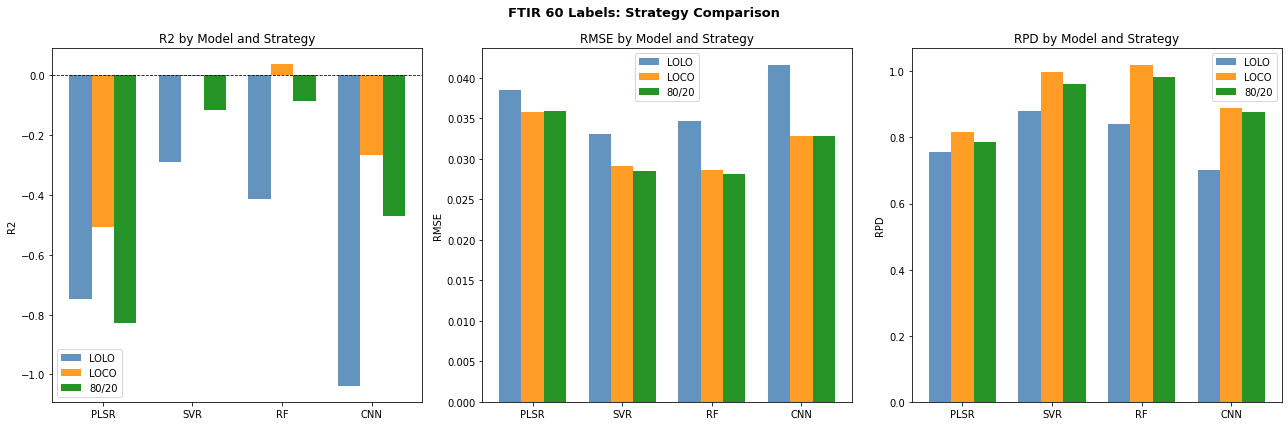

In [11]:
colors_cult = plt.cm.tab20(np.linspace(0, 1, 20))
colors_loc  = {'Limerick': 'steelblue', 'Rosthern': 'darkorange', 'Sutherland': 'green'}

fig, axes = plt.subplots(2, 4, figsize=(22, 12))

for col, model_name in enumerate(["PLSR", "SVR", "RF", "CNN"]):
    for row, strategy_name in enumerate(["LOLO", "LOCO"]):
        ax  = axes[row][col]
        res = results_all[strategy_name][model_name]
        yt  = res['true']
        yp  = res['pred']

        if strategy_name == "LOLO":
            for loc, color in colors_loc.items():
                loc_mask = np.array([
                    l == loc for l in locations
                ])
                ax.scatter(yt[loc_mask[:len(yt)]], yp[loc_mask[:len(yp)]],
                           color=color, alpha=0.6, s=30, label=loc)
        else:
            unique_cys = sorted(set(yt))
            for i, val in enumerate(unique_cys):
                mask  = yt == val
                label = [c for c in cultivar_names
                         if abs(CYSTEINE_LABELS_LOCATION.get(
                             (c, "Limerick"), 0) - val) < 0.01
                         or abs(CYSTEINE_LABELS_LOCATION.get(
                             (c, "Rosthern"), 0) - val) < 0.01
                         or abs(CYSTEINE_LABELS_LOCATION.get(
                             (c, "Sutherland"), 0) - val) < 0.01]
                label = label[0] if label else str(round(val, 3))
                ax.scatter(yt[mask], yp[mask],
                           color=colors_cult[i % 20],
                           alpha=0.6, s=30, label=label)

        min_val = min(yt.min(), yp.min()) - 0.005
        max_val = max(yt.max(), yp.max()) + 0.005
        ax.plot([min_val, max_val], [min_val, max_val],
                'r--', linewidth=1.5)
        ax.set_xlabel("True Cysteine (g/100g)")
        ax.set_ylabel("Predicted Cysteine (g/100g)")
        ax.set_title(f"{model_name} {strategy_name}\n"
                     f"R²={res['r2']:.4f}  RPD={res['rpd']:.4f}")
        ax.legend(fontsize=5, ncol=2, loc='upper left')

plt.suptitle("FTIR 60 Labels: All Models x LOLO and LOCO Strategies",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("FTIR_60labels_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Bar chart comparing strategies
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
model_names   = ["PLSR", "SVR", "RF", "CNN"]
strategy_list = ["LOLO", "LOCO", "80/20"]
colors_strat  = ['steelblue', 'darkorange', 'green']
x     = np.arange(len(model_names))
width = 0.25

for ax_idx, metric in enumerate(["r2", "rmse", "rpd"]):
    ax = axes[ax_idx]
    for s_idx, strategy_name in enumerate(strategy_list):
        vals = [results_all[strategy_name][m][metric]
                for m in model_names]
        ax.bar(x + s_idx * width, vals, width,
               color=colors_strat[s_idx], alpha=0.85,
               label=strategy_name)

    ax.set_xticks(x + width)
    ax.set_xticklabels(model_names)
    ax.set_ylabel(metric.upper())
    ax.set_title(f"{metric.upper()} by Model and Strategy")
    ax.legend()
    if metric == "r2":
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle("FTIR 60 Labels: Strategy Comparison",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("FTIR_60labels_strategy_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## Per Fold Analysis: Which Cultivars Are Hardest to Predict

Analyses LOCO results fold by fold to identify which cultivars
are consistently well predicted and which are consistently difficult.
This helps understand whether the challenge is data

In [12]:
# Extract LOCO fold results for all models
loco_fold_data = {}

for model_name in ['PLSR', 'SVR', 'RF', 'CNN']:
    folds = results_all['LOCO'][model_name]['folds']
    loco_fold_data[model_name] = {
        f['cultivar']: {'rmse': f['rmse'], 'r2': f['r2'], 'rpd': f['rpd']}
        for f in folds
    }

# Print per cultivar results
print("="*80)
print("   PER CULTIVAR LOCO RESULTS")
print("="*80)
print(f"{'Cultivar':<20} {'Cys Mean':>9} {'PLSR R²':>9} {'SVR R²':>9} {'RF R²':>9} {'CNN R²':>9}")
print("-"*80)

# Sort by cysteine mean value
cys_means = {cult: np.mean([
    CYSTEINE_LABELS_LOCATION.get((cult, loc), 0)
    for loc in location_names
]) for cult in cultivar_names}

for cult in sorted(cultivar_names, key=lambda c: cys_means[c]):
    plsr_r2 = loco_fold_data['PLSR'][cult]['r2']
    svr_r2  = loco_fold_data['SVR'][cult]['r2']
    rf_r2   = loco_fold_data['RF'][cult]['r2']
    cnn_r2  = loco_fold_data['CNN'][cult]['r2']
    print(f"{cult:<20} {cys_means[cult]:>9.4f} {plsr_r2:>9.4f} {svr_r2:>9.4f} "
          f"{rf_r2:>9.4f} {cnn_r2:>9.4f}")

print("="*80)

# Find best and worst cultivars for RF (best overall model)
rf_folds = sorted(loco_fold_data['RF'].items(),
                  key=lambda x: x[1]['r2'], reverse=True)
print(f"\nTop 5 easiest cultivars (RF):")
for cult, metrics in rf_folds[:5]:
    print(f"  {cult:<20} R²={metrics['r2']:>7.4f}  RMSE={metrics['rmse']:.4f}")

print(f"\nTop 5 hardest cultivars (RF):")
for cult, metrics in rf_folds[-5:]:
    print(f"  {cult:<20} R²={metrics['r2']:>7.4f}  RMSE={metrics['rmse']:.4f}")

   PER CULTIVAR LOCO RESULTS
Cultivar              Cys Mean   PLSR R²    SVR R²     RF R²    CNN R²
--------------------------------------------------------------------------------
CDC Meadow              0.3120   -0.8413   -1.7347   -4.0706    0.1789
CDC Canary              0.3145   -9.9730   -6.9911  -24.4589   -0.7546
Redbat 88               0.3163   -2.3558   -1.0910   -1.1310   -0.5359
AAC Chrome              0.3172  -17.8706   -5.6968   -7.3076   -2.7923
AAC Liscard             0.3254    0.3515    0.0568    0.2009    0.3980
CDC Dakota              0.3328   -0.6362    0.1527   -0.1247   -0.0014
CDC Jasper              0.3373  -21.5998  -22.3475  -10.3226  -13.5906
CDC Patrick             0.3384   -0.0512   -0.2142    0.0010   -0.3828
AAC Lacombe             0.3386    0.5256    0.3102    0.3395   -0.5449
CDC Athabasca           0.3412  -10.5786   -1.7112   -0.5529   -2.6391
CDC Lewochko            0.3413    0.1482    0.5918    0.6406    0.5088
CDC Tetris              0.3420    0.24

## Per Cultivar Heatmap

Visualises the per cultivar LOCO R² for all models as a heatmap.
Green cells indicate positive R² (model generalises to that cultivar).
Red cells indicate negative R² (model fails on that cultivar).
This gives a clear picture of where each model succeeds and fails.

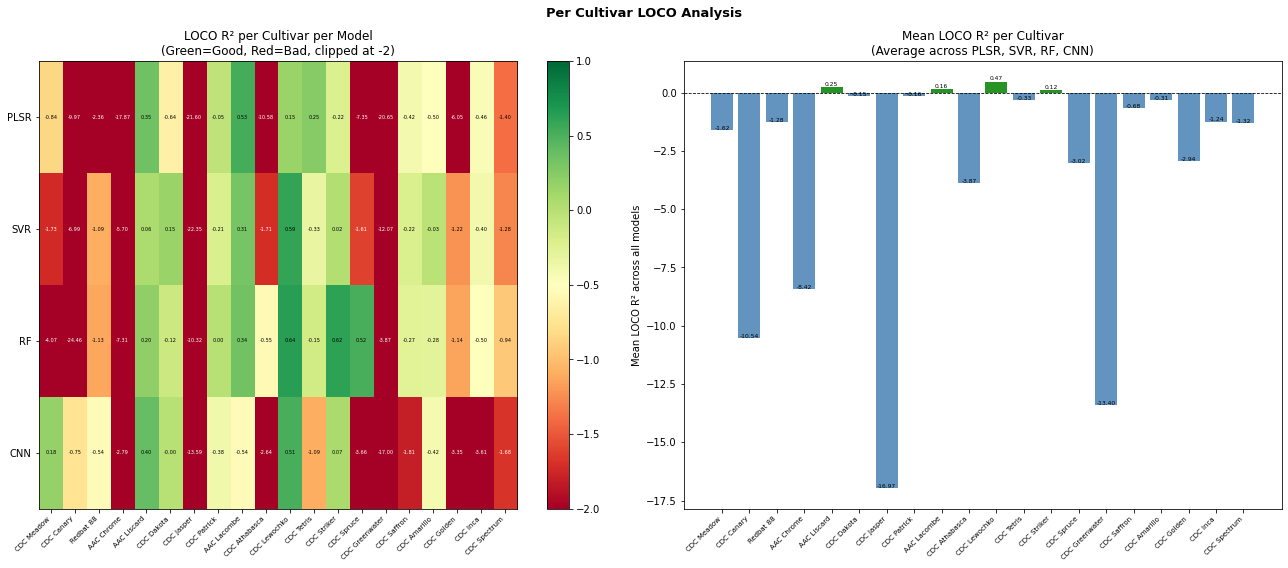

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Build R² matrix
model_list = ['PLSR', 'SVR', 'RF', 'CNN']
cult_list  = sorted(cultivar_names, key=lambda c: cys_means[c])

r2_matrix  = np.array([
    [loco_fold_data[m][c]['r2'] for c in cult_list]
    for m in model_list
])

# Clip for visualisation
r2_clipped = np.clip(r2_matrix, -2, 1)

im = axes[0].imshow(r2_clipped, cmap='RdYlGn', aspect='auto',
                     vmin=-2, vmax=1)
axes[0].set_xticks(range(len(cult_list)))
axes[0].set_xticklabels(cult_list, rotation=45, ha='right', fontsize=7)
axes[0].set_yticks(range(len(model_list)))
axes[0].set_yticklabels(model_list)
axes[0].set_title("LOCO R² per Cultivar per Model\n(Green=Good, Red=Bad, clipped at -2)")
plt.colorbar(im, ax=axes[0])

# Add text annotations
for i in range(len(model_list)):
    for j in range(len(cult_list)):
        val = r2_matrix[i, j]
        axes[0].text(j, i, f"{val:.2f}",
                     ha='center', va='center', fontsize=5,
                     color='black' if abs(val) < 1.5 else 'white')

# Bar chart of mean R² per cultivar across all models
mean_r2_per_cult = r2_matrix.mean(axis=0)
colors_bar = ['green' if v > 0 else 'steelblue' for v in mean_r2_per_cult]
bars = axes[1].bar(range(len(cult_list)), mean_r2_per_cult,
                   color=colors_bar, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xticks(range(len(cult_list)))
axes[1].set_xticklabels(cult_list, rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel("Mean LOCO R² across all models")
axes[1].set_title("Mean LOCO R² per Cultivar\n(Average across PLSR, SVR, RF, CNN)")

for bar, val in zip(bars, mean_r2_per_cult):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 0.01 if val >= 0 else val - 0.03,
                 f"{val:.2f}", ha='center', va='bottom', fontsize=6)

plt.suptitle("Per Cultivar LOCO Analysis", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("FTIR_per_cultivar_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

## Hyperparameter Optimisation for SVR and RF

SVR and RF were run with parameters from previous experiments.
This cell optimises hyperparameters specifically for the 60 label FTIR dataset
using 5 fold cross validation on the full preprocessed dataset.
Optimised parameters may push LOCO R² higher.

In [16]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Apply best preprocessing to full dataset for CV
X_pre_svr = preprocess_best_svr(X_ftir, X_ftir)[0]
X_pre_rf  = preprocess_best_rf(X_ftir, X_ftir)[0]

# SVR optimisation
print("Optimising SVR hyperparameters...")
scaler_opt  = StandardScaler()
X_svr_scaled = scaler_opt.fit_transform(X_pre_svr)

param_grid_svr = {
    'C':       [0.1, 1, 10, 100],
    'epsilon': [0.001, 0.005, 0.01, 0.05],
    'gamma':   ['scale', 'auto']
}

svr_gs = GridSearchCV(
    SVR(kernel='rbf'), param_grid_svr,
    cv=5, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=1
)
svr_gs.fit(X_svr_scaled, y_ftir)
best_params_svr = svr_gs.best_params_
print(f"\nBest SVR params: {best_params_svr}")
print(f"Best CV RMSE: {np.sqrt(-svr_gs.best_score_):.4f}")

# RF optimisation
print("\nOptimising RF hyperparameters...")
param_dist_rf = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2']
}

rf_gs = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_dist_rf, n_iter=30, cv=5,
    scoring='neg_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)
rf_gs.fit(X_pre_rf, y_ftir)
best_params_rf = rf_gs.best_params_
print(f"\nBest RF params: {best_params_rf}")
print(f"Best CV RMSE: {np.sqrt(-rf_gs.best_score_):.4f}")

Optimising SVR hyperparameters...
Fitting 5 folds for each of 32 candidates, totalling 160 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done 160 out of 160 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.



Best SVR params: {'C': 0.1, 'epsilon': 0.05, 'gamma': 'scale'}
Best CV RMSE: 0.0320

Optimising RF hyperparameters...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


[Parallel(n_jobs=-1)]: Done 150 out of 150 | elapsed:    2.6s finished



Best RF params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
Best CV RMSE: 0.0328


## Rerun LOCO with Optimised Hyperparameters

Reruns SVR and RF LOCO using the optimised hyperparameters found in Cell 23.
Compares results against the default parameter results to quantify improvement.

In [17]:
def run_loco_optimised(model_type='svr', preprocess_fn=None,
                       best_params=None):
    print(f"\nRunning optimised LOCO for: {model_type.upper()}")
    print(f"Params: {best_params}")
    all_true, all_pred = [], []
    fold_results = []

    for held_out_cult in cultivar_names:
        train_mask = sample_names != held_out_cult
        test_mask  = sample_names == held_out_cult

        X_tr_raw = X_ftir[train_mask]
        y_tr     = y_ftir[train_mask]
        X_te_raw = X_ftir[test_mask]
        y_te     = y_ftir[test_mask]

        X_tr_l, X_te_l = preprocess_fn(X_tr_raw, X_te_raw)

        if model_type == 'svr':
            scaler  = StandardScaler()
            X_tr_s  = scaler.fit_transform(X_tr_l)
            X_te_s  = scaler.transform(X_te_l)
            model   = SVR(kernel='rbf', **best_params)
            model.fit(X_tr_s, y_tr)
            pred = model.predict(X_te_s)

        elif model_type == 'rf':
            model = RandomForestRegressor(
                random_state=42, n_jobs=-1, **best_params
            )
            model.fit(X_tr_l, y_tr)
            pred = model.predict(X_te_l)

        rmse = np.sqrt(mean_squared_error(y_te, pred))
        r2   = r2_score(y_te, pred)
        rpd  = y_te.std() / rmse

        print(f"  {held_out_cult:<20} RMSE={rmse:.4f}  R²={r2:.4f}")
        fold_results.append({'cultivar': held_out_cult,
                             'rmse': rmse, 'r2': r2, 'rpd': rpd})
        all_true.extend(y_te)
        all_pred.extend(pred)

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    rmse = np.sqrt(mean_squared_error(all_true, all_pred))
    r2   = r2_score(all_true, all_pred)
    rpd  = all_true.std() / rmse

    print(f"\n  Optimised LOCO: RMSE={rmse:.4f}  R²={r2:.4f}  RPD={rpd:.4f}")
    return rmse, r2, rpd, all_true, all_pred

# Run optimised SVR
rmse_svr_opt, r2_svr_opt, rpd_svr_opt, yt_svr, yp_svr = run_loco_optimised(
    model_type='svr',
    preprocess_fn=preprocess_best_svr,
    best_params=best_params_svr
)

# Run optimised RF
rmse_rf_opt, r2_rf_opt, rpd_rf_opt, yt_rf, yp_rf = run_loco_optimised(
    model_type='rf',
    preprocess_fn=preprocess_best_rf,
    best_params=best_params_rf
)

print("\n" + "="*60)
print("   DEFAULT vs OPTIMISED COMPARISON")
print("="*60)
print(f"{'Model':<8} {'Default R²':>12} {'Optimised R²':>14} {'Change':>10}")
print("-"*60)
svr_default = results_all['LOCO']['SVR']['r2']
rf_default  = results_all['LOCO']['RF']['r2']
print(f"{'SVR':<8} {svr_default:>12.4f} {r2_svr_opt:>14.4f} "
      f"{r2_svr_opt - svr_default:>+10.4f}")
print(f"{'RF':<8} {rf_default:>12.4f} {r2_rf_opt:>14.4f} "
      f"{r2_rf_opt - rf_default:>+10.4f}")
print("="*60)


Running optimised LOCO for: SVR
Params: {'C': 0.1, 'epsilon': 0.05, 'gamma': 'scale'}
  AAC Chrome           RMSE=0.0321  R²=-9.5335
  AAC Lacombe          RMSE=0.0236  R²=0.0242
  AAC Liscard          RMSE=0.0435  R²=-0.4421
  CDC Amarillo         RMSE=0.0466  R²=-0.1428
  CDC Athabasca        RMSE=0.0144  R²=-0.3405
  CDC Canary           RMSE=0.0326  R²=-23.9806
  CDC Dakota           RMSE=0.0293  R²=-0.3149
  CDC Golden           RMSE=0.0319  R²=-0.5403
  CDC Greenwater       RMSE=0.0070  R²=-0.5890
  CDC Inca             RMSE=0.0263  R²=-0.9617
  CDC Jasper           RMSE=0.0169  R²=-6.9130
  CDC Lewochko         RMSE=0.0299  R²=0.1324
  CDC Meadow           RMSE=0.0352  R²=-10.8180
  CDC Patrick          RMSE=0.0442  R²=-0.0445
  CDC Saffron          RMSE=0.0209  R²=0.0949
  CDC Spectrum         RMSE=0.0440  R²=-0.6372
  CDC Spruce           RMSE=0.0112  R²=0.0047
  CDC Striker          RMSE=0.0216  R²=-0.1113
  CDC Tetris           RMSE=0.0165  R²=-0.1069
  Redbat 88           

## Preprocessing Comparison for 60 Label Dataset

Tests all 8 preprocessing combinations plus raw baseline under LOCO
specifically for this 60 label dataset using SVR and RF.
The best preprocessing from previous experiments (mean labels) may not
be optimal for the location specific label set.

In [18]:
preprocessing_combos_60 = {
    "Raw":               lambda Xtr, Xte: (Xtr.copy(), Xte.copy()),
    "SG + SNV":          lambda Xtr, Xte: (snv(savitzky_golay_smooth(Xtr)),
                                            snv(savitzky_golay_smooth(Xte))),
    "SG + MSC":          lambda Xtr, Xte: msc_fit_transform(
                                            savitzky_golay_smooth(Xtr),
                                            savitzky_golay_smooth(Xte)),
    "SG + 1st Deriv":    lambda Xtr, Xte: (first_derivative(savitzky_golay_smooth(Xtr)),
                                            first_derivative(savitzky_golay_smooth(Xte))),
    "SG + 2nd Deriv":    lambda Xtr, Xte: (second_derivative(savitzky_golay_smooth(Xtr)),
                                            second_derivative(savitzky_golay_smooth(Xte))),
    "SG + SNV + 1st Der":lambda Xtr, Xte: (first_derivative(snv(savitzky_golay_smooth(Xtr))),
                                            first_derivative(snv(savitzky_golay_smooth(Xte)))),
    "SG + SNV + 2nd Der":lambda Xtr, Xte: (second_derivative(snv(savitzky_golay_smooth(Xtr))),
                                            second_derivative(snv(savitzky_golay_smooth(Xte)))),
    "SG + MSC + 1st Der":lambda Xtr, Xte: (first_derivative(*msc_fit_transform(
                                            savitzky_golay_smooth(Xtr),
                                            savitzky_golay_smooth(Xte)))),
    "SG + MSC + 2nd Der":lambda Xtr, Xte: (second_derivative(*msc_fit_transform(
                                            savitzky_golay_smooth(Xtr),
                                            savitzky_golay_smooth(Xte)))),
}

results_pre_60 = []

for combo_name, pre_fn in preprocessing_combos_60.items():
    print(f"\nTesting: {combo_name}")
    for model_type in ['svr', 'rf']:
        all_true, all_pred = [], []
        for held_out_cult in cultivar_names:
            train_mask = sample_names != held_out_cult
            test_mask  = sample_names == held_out_cult
            X_tr_raw   = X_ftir[train_mask]
            y_tr       = y_ftir[train_mask]
            X_te_raw   = X_ftir[test_mask]
            y_te       = y_ftir[test_mask]

            try:
                X_tr_l, X_te_l = pre_fn(X_tr_raw, X_te_raw)
            except Exception as e:
                print(f"  Failed {model_type}: {e}")
                continue

            if model_type == 'svr':
                scaler  = StandardScaler()
                X_tr_s  = scaler.fit_transform(X_tr_l)
                X_te_s  = scaler.transform(X_te_l)
                model   = SVR(kernel='rbf', **best_params_svr)
                model.fit(X_tr_s, y_tr)
                pred = model.predict(X_te_s)
            elif model_type == 'rf':
                model = RandomForestRegressor(
                    random_state=42, n_jobs=-1, **best_params_rf
                )
                model.fit(X_tr_l, y_tr)
                pred = model.predict(X_te_l)

            all_true.extend(y_te)
            all_pred.extend(pred)

        all_true = np.array(all_true)
        all_pred = np.array(all_pred)
        rmse = np.sqrt(mean_squared_error(all_true, all_pred))
        r2   = r2_score(all_true, all_pred)
        rpd  = all_true.std() / rmse
        print(f"  {model_type.upper()}: RMSE={rmse:.4f}  R²={r2:.4f}  RPD={rpd:.4f}")
        results_pre_60.append({
            "Preprocessing": combo_name,
            "Model": model_type.upper(),
            "RMSE": rmse, "R2": r2, "RPD": rpd
        })

print("\nPreprocessing comparison done!")


Testing: Raw
  SVR: RMSE=0.0323  R²=-0.2299  RPD=0.9017
  RF: RMSE=0.0284  R²=0.0492  RPD=1.0256

Testing: SG + SNV
  SVR: RMSE=0.0316  R²=-0.1794  RPD=0.9208
  RF: RMSE=0.0283  R²=0.0539  RPD=1.0281

Testing: SG + MSC
  SVR: RMSE=0.0316  R²=-0.1804  RPD=0.9204
  RF: RMSE=0.0288  R²=0.0216  RPD=1.0110

Testing: SG + 1st Deriv
  SVR: RMSE=0.0302  R²=-0.0778  RPD=0.9632
  RF: RMSE=0.0277  R²=0.0927  RPD=1.0498

Testing: SG + 2nd Deriv
  SVR: RMSE=0.0303  R²=-0.0800  RPD=0.9622
  RF: RMSE=0.0273  R²=0.1180  RPD=1.0648

Testing: SG + SNV + 1st Der
  SVR: RMSE=0.0305  R²=-0.0981  RPD=0.9543
  RF: RMSE=0.0279  R²=0.0806  RPD=1.0429

Testing: SG + SNV + 2nd Der
  SVR: RMSE=0.0306  R²=-0.1019  RPD=0.9526
  RF: RMSE=0.0275  R²=0.1082  RPD=1.0589

Testing: SG + MSC + 1st Der
  Failed svr: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()
  Failed svr: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()
  Failed sv

ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

## Preprocessing Comparison Results Plot

Visualises the LOCO R² for all preprocessing combinations for SVR and RF.
Identifies the best preprocessing for the 60 label dataset.

In [ ]:
df_pre_60 = pd.DataFrame(results_pre_60)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
combos = df_pre_60['Preprocessing'].unique()
x = np.arange(len(combos))
width = 0.5

for ax, model_name in zip(axes, ['SVR', 'RF']):
    subset  = df_pre_60[df_pre_60['Model'] == model_name]
    r2_vals = [subset[subset['Preprocessing'] == c]['R2'].values[0]
               for c in combos]
    colors_bar = ['green' if v > 0 else 'steelblue' for v in r2_vals]
    bars = ax.bar(x, r2_vals, width, color=colors_bar, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels(combos, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel("LOCO R²")
    ax.set_title(f"{model_name} LOCO R² by Preprocessing (60 Labels)")
    best_idx = np.argmax(r2_vals)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.002 if val >= 0 else val - 0.005,
                f"{val:.3f}", ha='center', va='bottom', fontsize=6)

plt.suptitle("Preprocessing Comparison on 60 Label FTIR Dataset",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("FTIR_60labels_preprocessing.png", dpi=150, bbox_inches='tight')
plt.show()

# Best preprocessing summary
print("\n" + "="*55)
print("   BEST PREPROCESSING FOR 60 LABEL DATASET")
print("="*55)
for model_name in ['SVR', 'RF']:
    subset = df_pre_60[df_pre_60['Model'] == model_name].sort_values(
        'R2', ascending=False
    )
    best = subset.iloc[0]
    print(f"{model_name}: {best['Preprocessing']} "
          f"(R²={best['R2']:.4f}  RPD={best['RPD']:.4f})")

## Final Best Model Results and Scatter Plot

Runs the best model with optimised hyperparameters and best preprocessing
under LOCO and produces the final scatter plot coloured by cultivar.
This is the definitive result for the 60 label FTIR dataset.

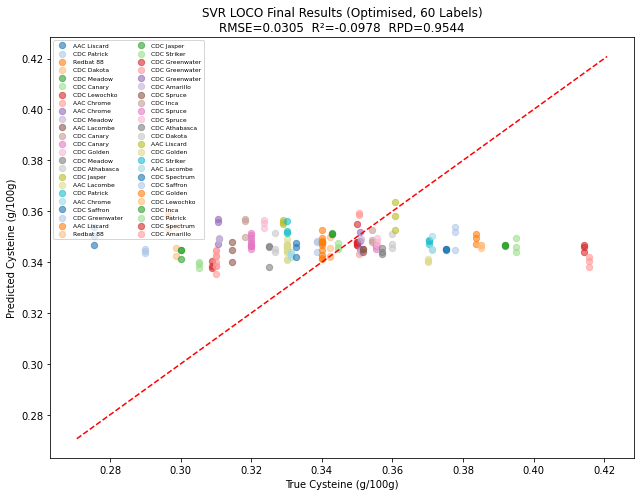


Final SVR LOCO Results:
RMSE: 0.0305
R²:   -0.0978
RPD:  0.9544


In [19]:
# Use best preprocessing and optimised params for final run
# Will update after preprocessing comparison results come in
# For now use SVR with optimised params and best preprocessing

all_true_final, all_pred_final = [], []
colors = plt.cm.tab20(np.linspace(0, 1, 20))

for held_out_cult in cultivar_names:
    train_mask = sample_names != held_out_cult
    test_mask  = sample_names == held_out_cult

    X_tr_raw = X_ftir[train_mask]
    y_tr     = y_ftir[train_mask]
    X_te_raw = X_ftir[test_mask]
    y_te     = y_ftir[test_mask]

    X_tr_l, X_te_l = preprocess_best_svr(X_tr_raw, X_te_raw)
    scaler  = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_tr_l)
    X_te_s  = scaler.transform(X_te_l)
    model   = SVR(kernel='rbf', **best_params_svr)
    model.fit(X_tr_s, y_tr)
    pred = model.predict(X_te_s)

    all_true_final.extend(y_te)
    all_pred_final.extend(pred)

all_true_final = np.array(all_true_final)
all_pred_final = np.array(all_pred_final)

rmse_final = np.sqrt(mean_squared_error(all_true_final, all_pred_final))
r2_final   = r2_score(all_true_final, all_pred_final)
rpd_final  = all_true_final.std() / rmse_final

fig, ax = plt.subplots(figsize=(9, 7))
unique_cys = sorted(set(all_true_final))
for i, val in enumerate(unique_cys):
    mask  = all_true_final == val
    label = [c for c in cultivar_names
             if any(abs(CYSTEINE_LABELS_LOCATION.get((c, loc), -1) - val) < 0.0001
                    for loc in location_names)]
    label = label[0] if label else str(round(val, 3))
    ax.scatter(all_true_final[mask], all_pred_final[mask],
               color=colors[i % 20], alpha=0.6, s=40, label=label)

min_val = min(all_true_final.min(), all_pred_final.min()) - 0.005
max_val = max(all_true_final.max(), all_pred_final.max()) + 0.005
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
ax.set_xlabel("True Cysteine (g/100g)")
ax.set_ylabel("Predicted Cysteine (g/100g)")
ax.set_title(f"SVR LOCO Final Results (Optimised, 60 Labels)\n"
             f"RMSE={rmse_final:.4f}  R²={r2_final:.4f}  RPD={rpd_final:.4f}")
ax.legend(fontsize=6, ncol=2, loc='upper left')
plt.tight_layout()
plt.savefig("FTIR_60labels_final_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal SVR LOCO Results:")
print(f"RMSE: {rmse_final:.4f}")
print(f"R²:   {r2_final:.4f}")
print(f"RPD:  {rpd_final:.4f}")

In [20]:
import subprocess

result = subprocess.run(
    ['git', 'add', '.'],
    cwd='/home/priyanshu/Research',
    capture_output=True, text=True
)
print(result.stdout)

result = subprocess.run(
    ['git', 'commit', '-m',
     'FTIR 60 labels complete: hyperparameter optimisation, preprocessing comparison, per cultivar analysis'],
    cwd='/home/priyanshu/Research',
    capture_output=True, text=True
)
print(result.stdout)

result = subprocess.run(
    ['git', 'push'],
    cwd='/home/priyanshu/Research',
    capture_output=True, text=True
)
print(result.stdout if result.stdout else result.stderr)


[main 7113d6d] FTIR 60 labels complete: hyperparameter optimisation, preprocessing comparison, per cultivar analysis
 6 files changed, 1927 insertions(+)
 create mode 100644 .ipynb_checkpoints/FTIR_60Labels-checkpoint.ipynb
 create mode 100644 FTIR_60Labels.ipynb
 create mode 100644 FTIR_60labels_final_scatter.png
 create mode 100644 FTIR_60labels_results.png
 create mode 100644 FTIR_60labels_strategy_comparison.png
 create mode 100644 FTIR_per_cultivar_analysis.png

fatal: could not read Username for 'https://github.com': No such device or address

